# Data load

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import clear_output
from datetime import datetime
import pickle
from datetime import datetime
import math
import scanpy as sc
from adjustText import adjust_text
import seaborn as sns

pd.options.display.max_rows = 2000

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects

# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[ '#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [3]:
from module.misc import sample_name_import

name_dir = "circa-SD"
# name_dir = "all-samples-C123"
# name_dir = 'all-samples'

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


In [4]:
dir_notebook = '../notebook'
# dir_notebook = 'D:\Jupyter_notebook\Xenium_jupyter_notebook'


In [4]:
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')

In [16]:
df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
df.shape

from module.xenium_preprocessing import add_annotations

df = add_annotations(adata, df)

In [ ]:
df.to_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

In [5]:
df = pd.read_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

In [48]:
gene = 'Gabbr1'

celltype = 'STR_D2_Gaba'

# df[(df['cell_type_final']==celltype)
#    &(df[gene]>0)
#    ][gene].hist(bins=100)
# df[df['cell_type_final']==celltype].shape

from module.misc import genes_list

markers = genes_list('panel_5k_circa')

df[(df['cell_type_final']==celltype)][markers].mean()

A1cf      0.000323
A2m       0.000954
Aatf      0.059065
Abca1     0.016128
Abca13    0.000284
            ...   
Zswim9    0.026839
Zup1      0.016823
Zyx       0.014319
Zzef1     0.123299
a         0.000253
Length: 4655, dtype: float32

In [12]:
plt.hist(df['Gfap'], df['transcript_counts'])

AttributeError: module 'seaborn' has no attribute 'histo'

# Load data

In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import clear_output
from datetime import datetime
import pickle
from datetime import datetime
import math
import scanpy as sc
from adjustText import adjust_text

pd.options.display.max_rows = 2000

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects


# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[ '#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [26]:
from module.misc import sample_name_import

name_dir = "circa-SD"
# name_dir = "all-samples"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


In [27]:
dir_notebook = '../notebook'
# dir_notebook = 'D:\Jupyter_notebook\Xenium_jupyter_notebook'


In [28]:
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')

In [29]:
df = pd.read_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

In [9]:
## SD dendro order

order_list = ['Oligodendrocyte', 'Microglia', 'Choroid', 'ABC', 'VLMC', 'OB_STR_CTX_Inh_IMN', 'Ependymal', 'Tanycyte', 'OPC', 'Astrocyte', 'Endothelial', 'Pericyte', 'PVH_SO_Glut', 'PVR_Gaba', 'SCH_Gaba', 'MH_Glut', 'TRS_BAC_Glut', 'DG_PIR_Ex_IMN', 'HPF_CR_Glut', 'LSX_Gaba', 'CEA_AAA_BST_Gaba', 'STR_PAL_Gaba', 'Sst_Gaba', 'Lamp5_Gaba', 'Vip_Gaba', 'Pvalb_Gaba', 'STR_Gaba', 'RT_ZI_Gaba', 'SI_Gaba', 'ATN_Glut', 'PT_Glut', 'RE_Glut', 'AD_Glut', 'AV_Glut', 'TH_Glut', 'LSX_Glut', 'BST_MPN_Gaba', 'COAa_PAA_MEA_Glut', 'PAL_STR_Gaba_Chol', 'PVT_Glut', 'BST_po_Glut', 'LH_Glut', 'MEA_Glut', 'AHN_Glut', 'LHA_Glut', 'STR_D1_Gaba', 'STR_D2_Gaba', 'DG_Glut', 'CA1_ProS_Glut', 'CA2_FC_IG_Glut', 'CA3_Glut', 'L2_3_IT_CTX_Glut', 'L4_5_IT_CTX_Glut', 'L4_RSP_ACA_Glut', 'L2_3_IT_RSP_Glut', 'L5_ET_CTX_Glut', 'L5_NP_CTX_Glut', 'L6_IT_CTX_Glut', 'L6_CT_CTX_Glut', 'L6b_CTX_Glut', 'CLA_EPd_CTX_Glut', 'L2_3_IT_PIR_ENTl_Glut', 'NLOT_Glut']


# Cell Population

In [31]:
grouped = df.groupby(['run','sample','region_automap_name'])['cell_type_final'].value_counts(dropna=True)
grouped.to_csv(f'data/cell_count_region_{name_dir}.csv')

In [32]:
import math
df = pd.read_csv(f'data/cell_count_region_{name_dir}.csv')

df = df[df['count'] > 10]

df_nbcells_av = []
df_nbcells_sem = []
df_nbcells_pct = []

all_regions = df['region_automap_name'].unique()
all_celltypes = df['cell_type_final'].unique()

for region in all_regions:
    dat_av = pd.DataFrame()
    dat_sem = pd.DataFrame()
    dat_pct = pd.DataFrame()
    
    for cell in all_celltypes:
        temp_av = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].mean()
        tempdf = pd.DataFrame(data = {cell : temp_av})
        dat_av = pd.concat([dat_av, tempdf], axis=1)

        temp_percent = df[(df['cell_type_final']== cell)& (df['region_automap_name'] == region) ].groupby('run')['count'].sum() / df[df['region_automap_name'] == region].groupby('run')['count'].sum() * 100
        tempdf = pd.DataFrame(data = {cell : temp_percent}) 
        dat_pct = pd.concat([dat_pct, tempdf], axis=1)  

        temp_sem = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].std() / df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].count()
        tempdf = pd.DataFrame(data = {cell : temp_sem})
        dat_sem = pd.concat([dat_sem, tempdf], axis=1)
    
    df_nbcells_sem.append(dat_sem)
    df_nbcells_av.append(dat_av)
    df_nbcells_pct.append(dat_pct)

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_av[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_sem[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_pct[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

In [33]:
df_average = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', sheet_name=None)
df_std = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', sheet_name=None)
df_pct = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', sheet_name=None)

df_average = {key: value for key, value in sorted(df_average.items())}
df_std = {key: value for key, value in sorted(df_std.items())}
df_pct = {key: value for key, value in sorted(df_pct.items())}


df_average.pop('VLMC')
df_average.pop('Ependymal')
# df_average.pop('CHOR')
# df_average.pop('Tanycyte')

# df_std.pop('Tanycyte')
df_std.pop('VLMC')
# df_std.pop('CHOR')
df_std.pop('Ependymal')

# df_pct.pop('Tanycyte')
df_pct.pop('VLMC')
# df_pct.pop('CHOR')
df_pct.pop('Ependymal')
# df_pct.pop('AD')

,AHN_Glut,Astrocyte,Oligodendrocyte,BST_MPN_Gaba,Endothelial,LHA_Glut,Microglia,OPC,Pericyte,COAa_PAA_MEA_Glut,...,MH_Glut,DG_Glut,CA3_Glut,CA2_FC_IG_Glut,CA1_ProS_Glut,LH_Glut,RT_ZI_Gaba,LSX_Glut,PT_Glut,AD_Glut
0,NaN,15.709077,11.003252,1.128412,1.670444,1.010151,1.138267,1.093919,0.502612,NaN,...,0.561742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,12.309230,17.087573,0.849382,2.275618,0.531432,1.121911,1.353561,0.413336,NaN,...,0.490552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df_average['Choroid']

,AHN_Glut,Astrocyte,Oligodendrocyte,BST_MPN_Gaba,Endothelial,LHA_Glut,Microglia,OPC,Pericyte,COAa_PAA_MEA_Glut,...,MH_Glut,DG_Glut,CA3_Glut,CA2_FC_IG_Glut,CA1_ProS_Glut,LH_Glut,RT_ZI_Gaba,LSX_Glut,PT_Glut,AD_Glut
0,NaN,23.75,133.000000,NaN,90.400000,NaN,11.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,53.40,55.666667,NaN,140.833333,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df[(df['cell_type_final']== "Astro TE") & (df['region_automap_name'] == "SCH")].groupby('run')['count'].mean()

In [38]:
adata[adata.obs['region_automap_name']=="Choroid"].obs.groupby(['run','sample'])['cell_type_final'].value_counts()

/tmp/ipykernel_36234/4097584170.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata[adata.obs['region_automap_name']=="Choroid"].obs.groupby(['run','sample'])['cell_type_final'].value_counts(dropna=True)


run     sample           cell_type_final      
SD1     SD1-ZT01         Choroid                  1277
                         VLMC                      118
                         Ependymal                  90
                         Endothelial                84
                         OB_STR_CTX_Inh_IMN         64
                         Astrocyte                  17
                         Microglia                   3
                         Pericyte                    3
                         STR_D2_Gaba                 1
                         ABC                         0
                         BST_MPN_Gaba                0
                         BST_po_Glut                 0
                         HPF_CR_Glut                 0
                         L2_3_IT_PIR_ENTl_Glut       0
                         L4_5_IT_CTX_Glut            0
                         L6_CT_CTX_Glut              0
                         LSX_Gaba                    0
                  

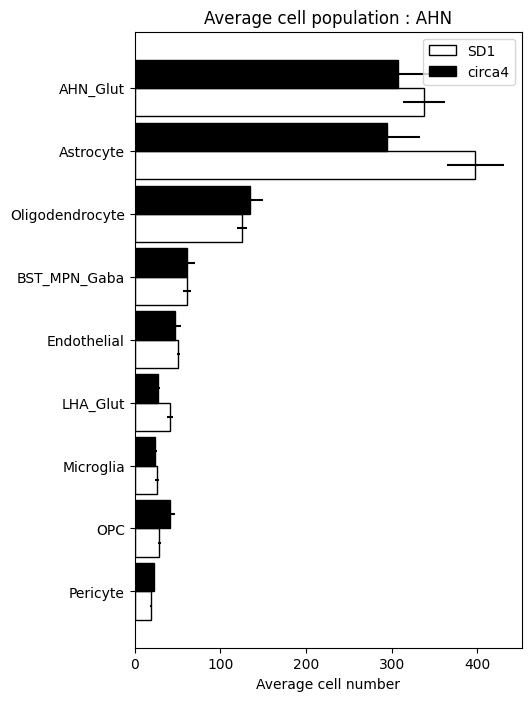

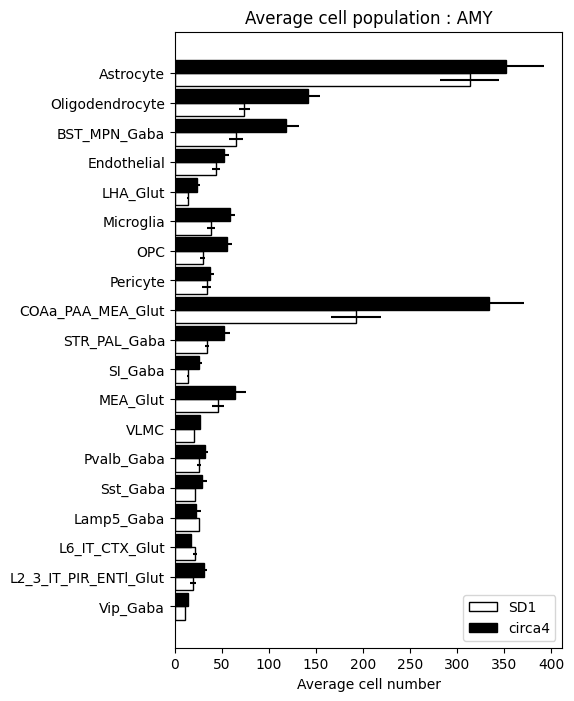

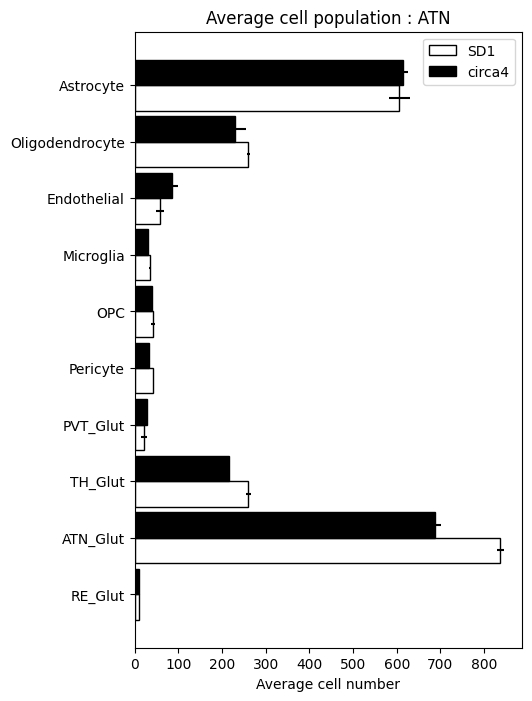

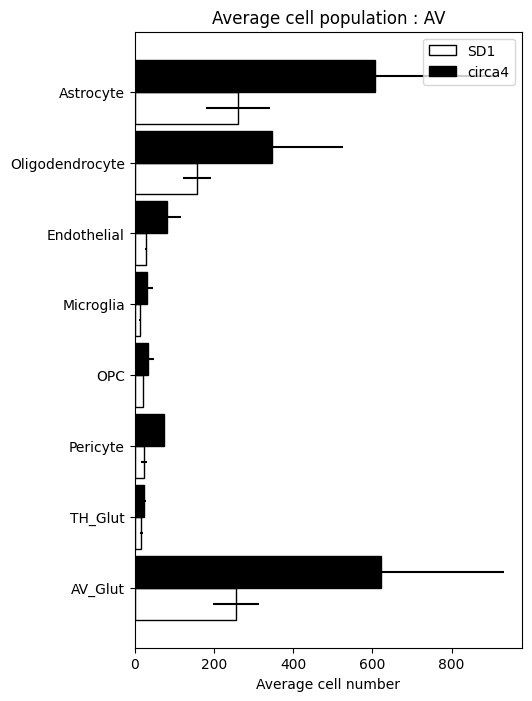

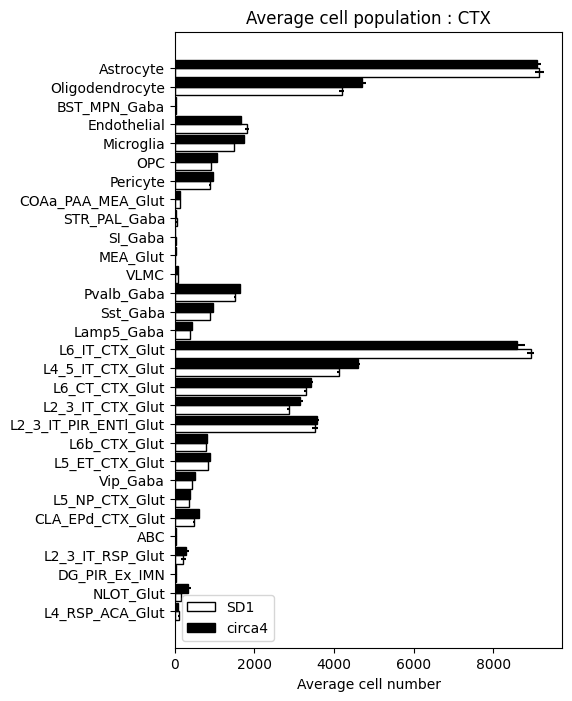

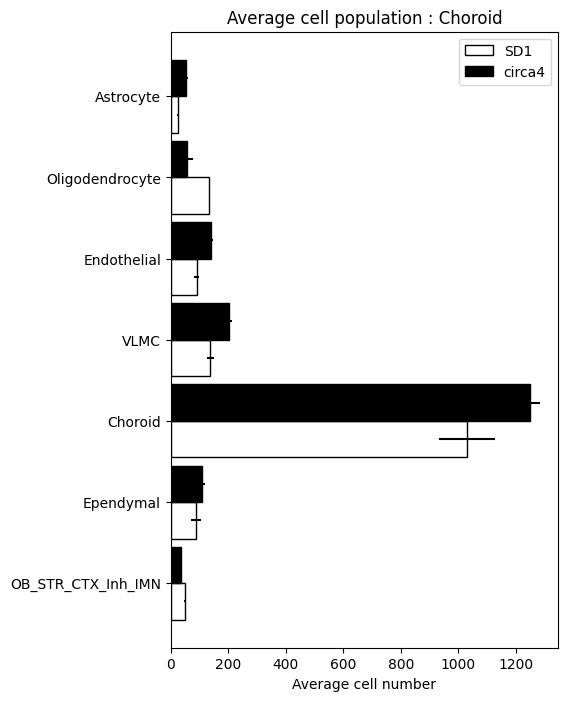

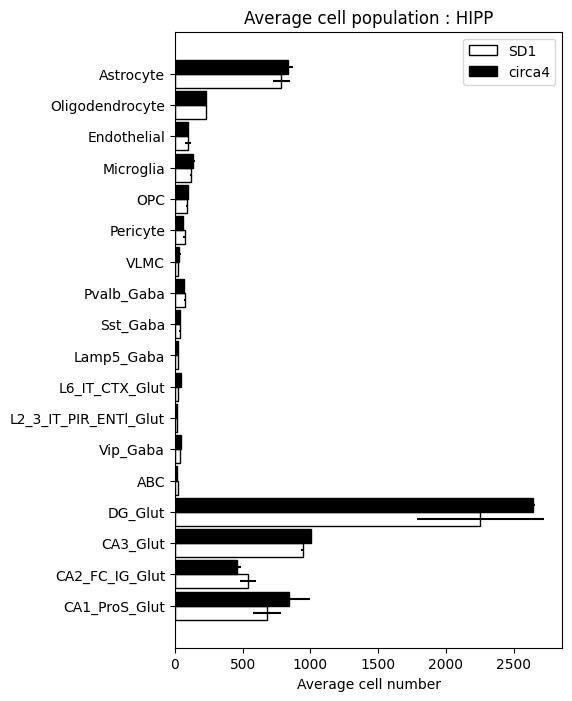

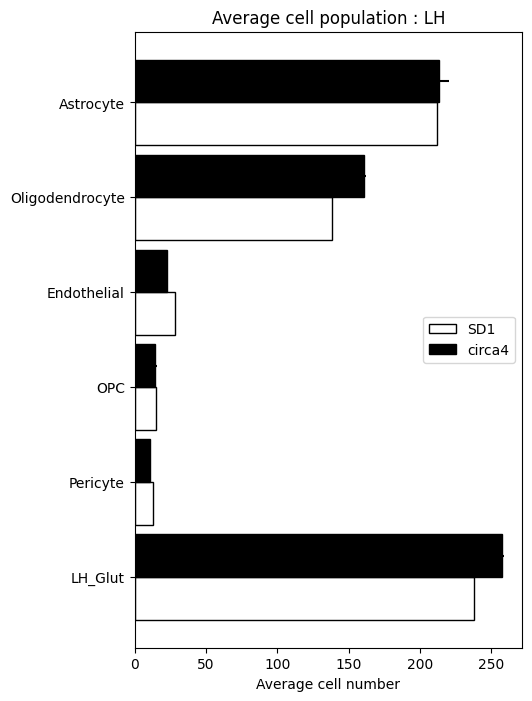

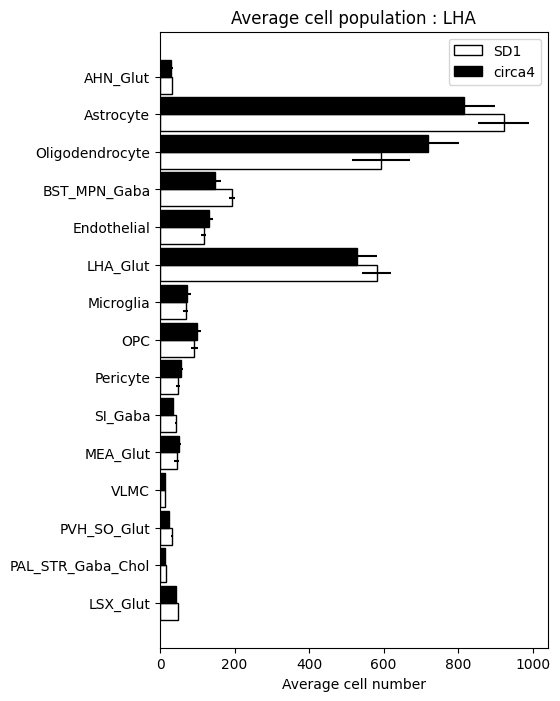

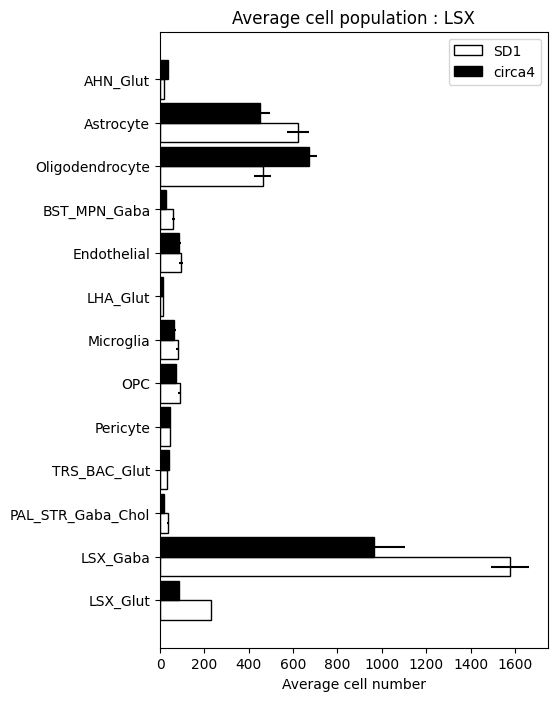

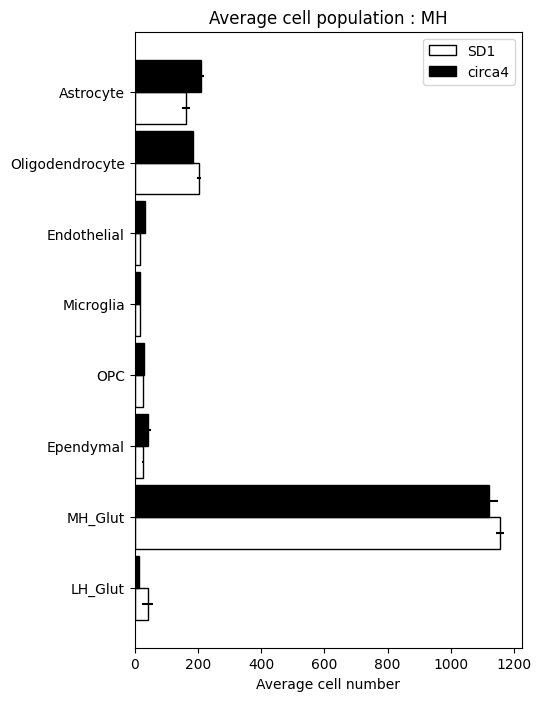

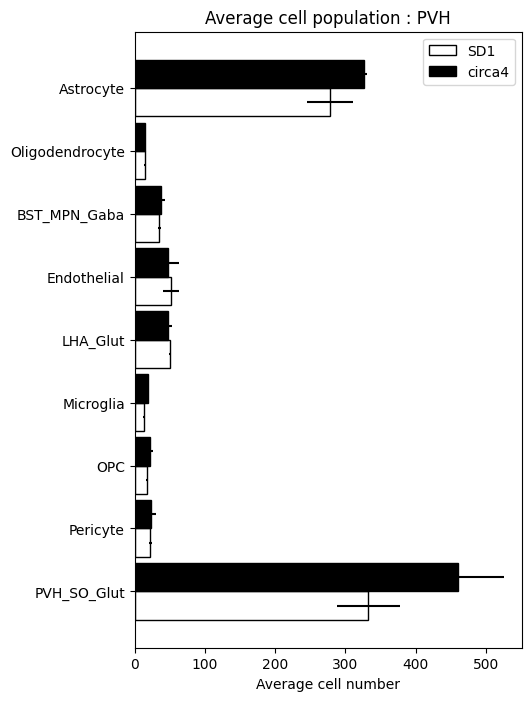

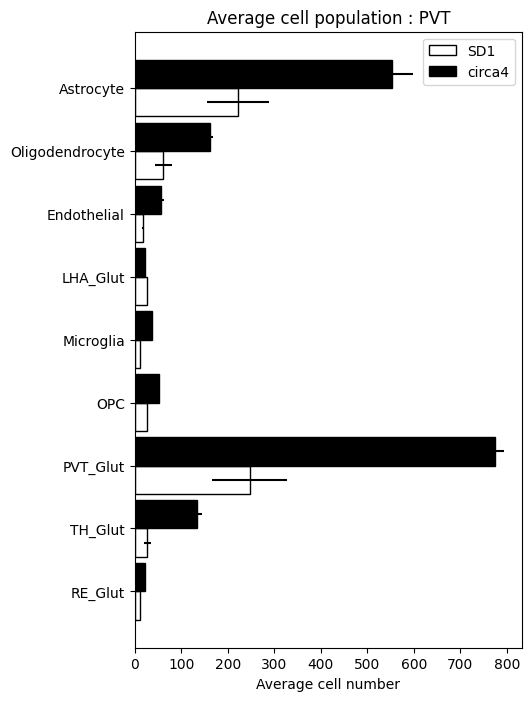

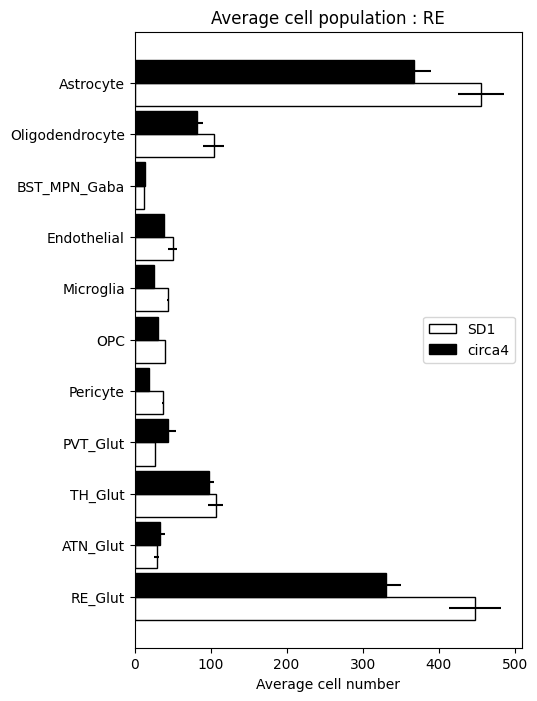

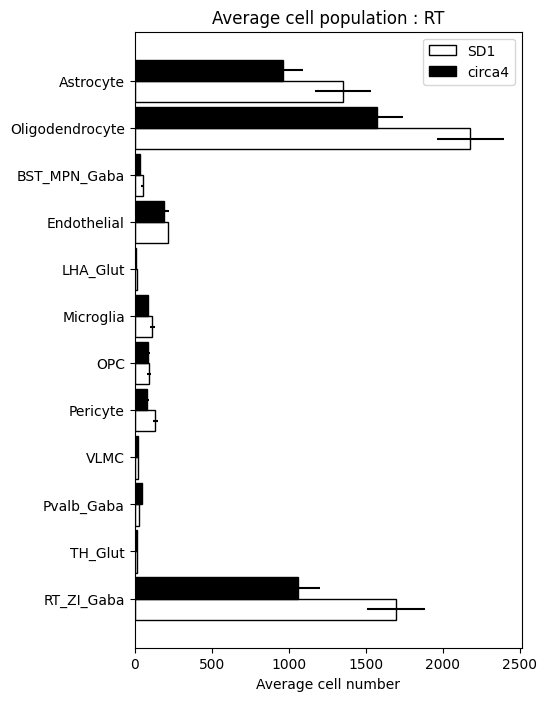

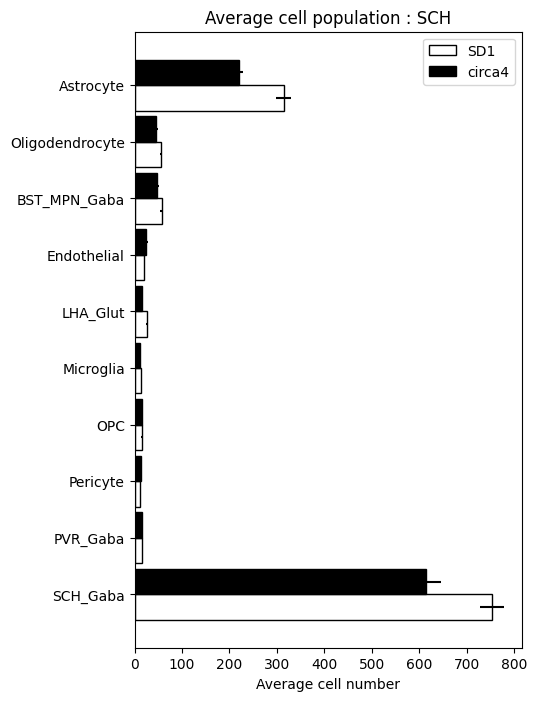

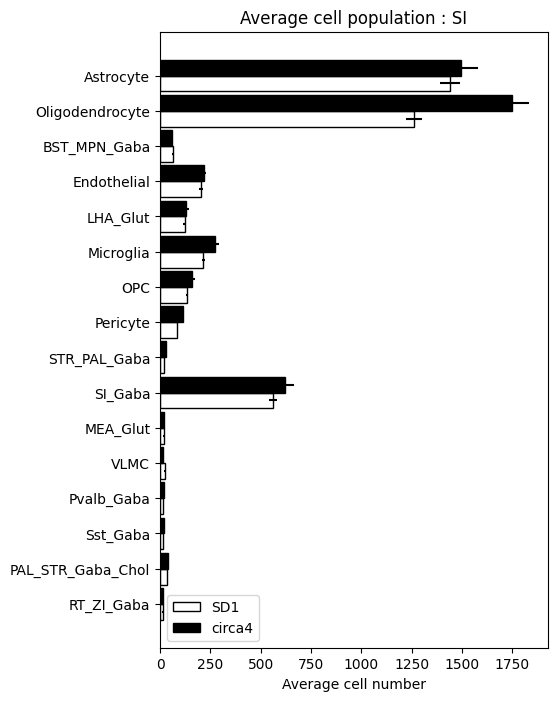

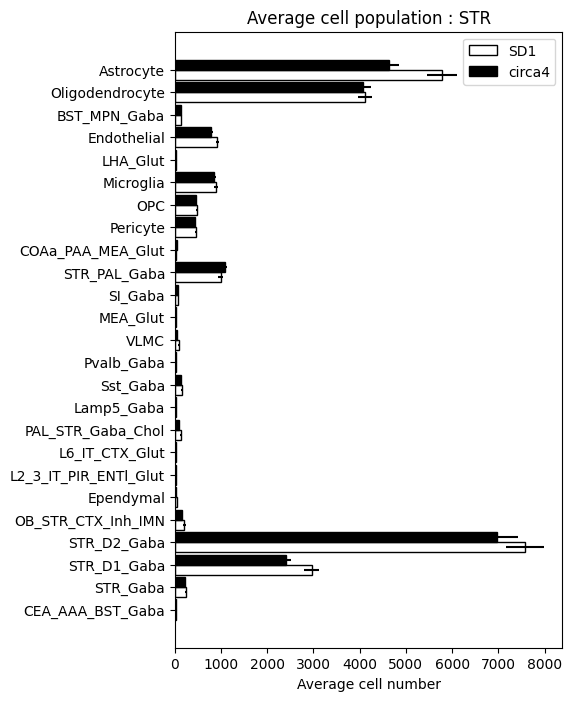

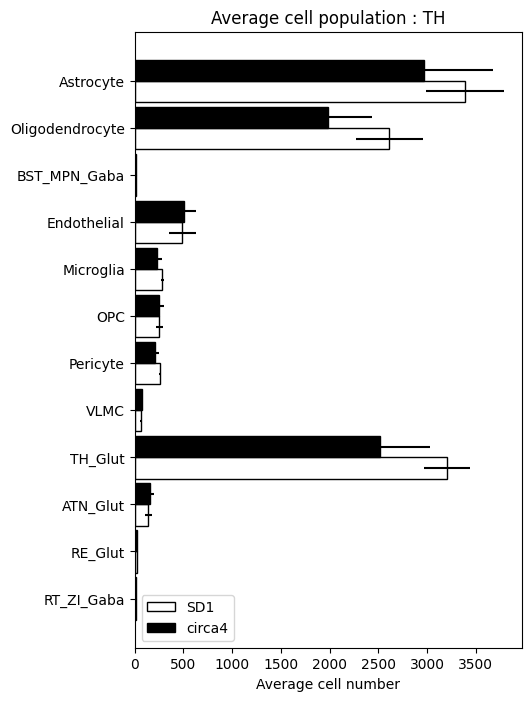

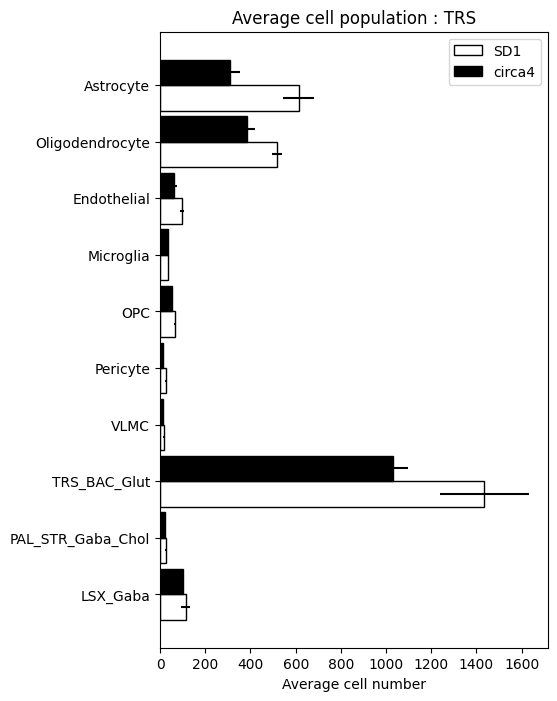

In [45]:
group = ['SD1','circa4']

for key in df_pct.keys():
    if key == 'PT':
        continue
    elif key == 'Tanycyte':
        continue
    elif key == 'B':
        continue
    elif key == 'A':
        continue
    elif key == 'BST':
        continue
    elif key == 'AD':
        continue
    print(key)
    df_average[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_average[key].columns]
    df_average[key].index = group
    df_std[key].index = group

    plt.figure(figsize=(5,8))
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T[group[0]],
           height= 0.45, align='edge', label = group[0],edgecolor='black',color = 'white',
           xerr= df_std[key].T[group[0]] )
    
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T[group[1]],
           height= -0.45, align='edge', label = group[1],edgecolor='black', color = 'black',
           xerr= df_std[key].T[group[1]]
           )

    plt.gca().invert_yaxis()

    plt.xlabel('Average cell number')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig(f'Gallery/{today}/celltype_region/{name_dir}_cellnb_{key}.svg')
    clear_output()

In [ ]:
len(df_pct[key])

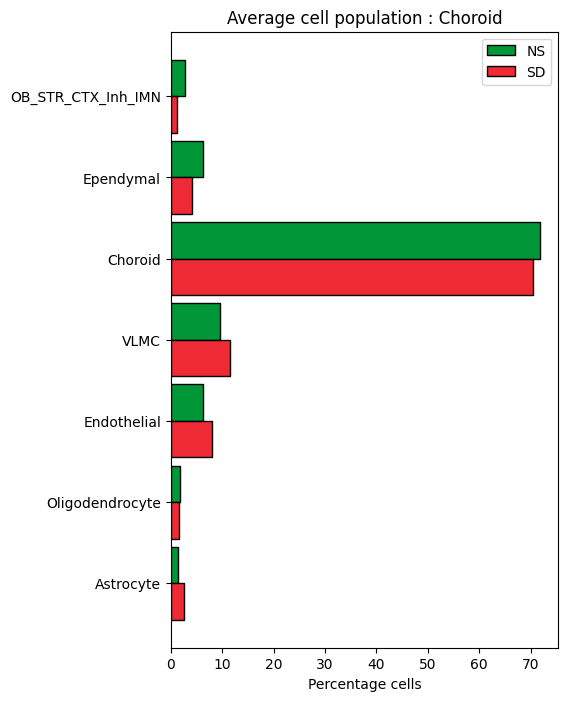

In [46]:
for key in ['Choroid']:
    if len(df_pct[key]) == 1:
        continue
    df_pct[key] = df_pct[key][df_pct[key].select_dtypes(np.number).gt(0.5)]
    df_pct[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_pct[key].columns]
    df_pct[key].index = ['NS','SD']
    df_std[key].index = ['NS','SD']

    plt.figure(figsize=(5,8))
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['NS'],
           height= 0.45, align='edge', label = 'NS',edgecolor='black',
           )
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['SD'],
           height= -0.45, align='edge', label = 'SD',edgecolor='black',
           )
    plt.xlabel('Percentage cells')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig('Gallery/circa-SD_cellnb.svg')
    clear_output()

# Cell population dendro order

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
cell_nb = pd.read_csv(f'{dir_notebook}/analysis/{name_dir}/summary_cell_number.csv')
cell_nb.sample(5)

,run,sample,cell_type_final,count
850,circa4,SD1-ZT05,LH_Glut,0
785,circa4,SD1-ZT01,L6b_CTX_Glut,0
105,SD1,SD1-ZT05,AV_Glut,345
47,SD1,SD1-ZT01,L2_3_IT_RSP_Glut,13
280,SD1,SD1-ZT17,Lamp5_Gaba,476


In [10]:
from module.misc import cell_class

dict_temp = cell_class()

cell_nb['cell_class'] = cell_nb['cell_type_final'].apply(lambda x: dict_temp[x] if x in dict_temp.keys() else "Neuron")
cell_nb.sample()

cell_nb["Celltype_order"] = pd.Categorical(cell_nb['cell_type_final'], categories=order_list, ordered = True)
cell_nb.sort_values('Celltype_order', inplace= True)

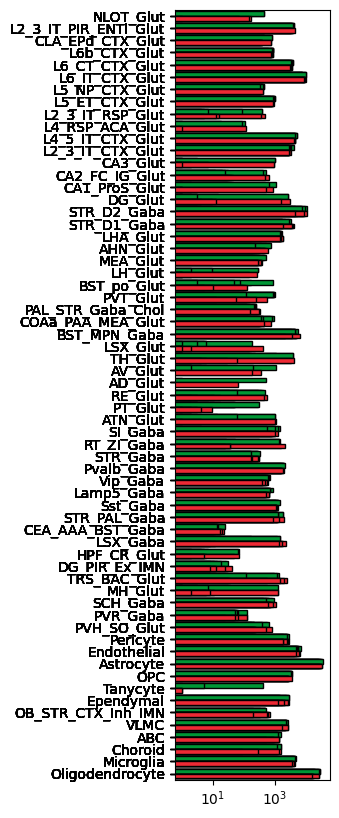

In [15]:
param = 'run'
group1 = "circa4"
group2 = 'SD1'

plt.figure(figsize=(2,10))
plt.barh(y=cell_nb['cell_type_final'][cell_nb[param]==group1],
         width=cell_nb[cell_nb[param]==group1]['count'],
           height = 0.4, align='edge', edgecolor ='black')
plt.barh(y=cell_nb['cell_type_final'][cell_nb[param]==group2],
         width=cell_nb[cell_nb[param]==group2]['count'],
           height= -0.4, align='edge', edgecolor ='black')
plt.yticks(ticks=cell_nb['cell_type_final'][cell_nb[param]==group2], rotation=0)
plt.xscale('log')
plt.ylim(-0.5,62.5)
plt.savefig(f'Gallery/{today}/{name_dir}_cellnb.svg')

## Cell pop hierarchical order

In [ ]:
df = df[~(df['cell_type_final'] == 'Undefined')]
# df = df[~(df['cell_type_final'] == 'AD Glut')]

In [16]:
cell_pop = df.groupby(['cell_type_final','run'])["ZT"].count()
cell_pop.head()

cell_type_final  run   
ABC              SD1       6310
                 circa4    7148
AD_Glut          SD1         66
                 circa4     509
AHN_Glut         SD1       2539
Name: ZT, dtype: int64

In [ ]:
# cell_pop = pd.read_csv(f'../notebook/analysis/{name_dir}/{name_dir}_cellpop.csv')
# circa_pct = pd.read_csv('../notebook/analysis/circa-SD/circa-SD_circa-percent.csv')

In [17]:
cell_pop = pd.DataFrame(data = {"cell_type_final" : cell_pop.index,
                                "count" : cell_pop.values})
# cell_pop.rename(columns={"ZT" : "count"})


In [18]:
from module.misc import cell_class

cell_pop[['celltype','genotype']] = cell_pop['cell_type_final'].apply(pd.Series)

class_dict = cell_class()
cell_pop['cell_class'] = 'Neuron'
cell_pop['cell_class'] = cell_pop['celltype'].map(class_dict)
cell_pop['cell_class'] = cell_pop['cell_class'].fillna('Neuron')

cell_pop

,cell_type_final,count,celltype,genotype,cell_class
0,"(ABC, SD1)",6310,ABC,SD1,Vascular
1,"(ABC, circa4)",7148,ABC,circa4,Vascular
2,"(AD_Glut, SD1)",66,AD_Glut,SD1,Neuron
3,"(AD_Glut, circa4)",509,AD_Glut,circa4,Neuron
4,"(AHN_Glut, SD1)",2539,AHN_Glut,SD1,Neuron
5,"(AHN_Glut, circa4)",2687,AHN_Glut,circa4,Neuron
6,"(ATN_Glut, SD1)",2050,ATN_Glut,SD1,Neuron
7,"(ATN_Glut, circa4)",2074,ATN_Glut,circa4,Neuron
8,"(AV_Glut, SD1)",523,AV_Glut,SD1,Neuron
9,"(AV_Glut, circa4)",1283,AV_Glut,circa4,Neuron


In [19]:
# cell_pop['cell_type_final'] = cell_pop.index
cell_pop.sort_values(by='cell_type_final', inplace=True, ignore_index=True)
# circa_pct.sort_values(by='cell_type_final', inplace=True, ignore_index=True)


In [20]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k_circa')
df_CG = df.filter(clock_genes, axis = 1)

In [21]:
df_CG['cell_type_final'] = df['cell_type_final']
df_CG.sample() 

,A1cf,A2m,Aatf,Abca1,Abca13,Abca3,Abca4,Abca7,Abca8a,Abca8b,...,Zp1,Zscan2,Zscan21,Zswim5,Zswim9,Zup1,Zyx,Zzef1,a,cell_type_final
circa4-IGM-ZT13_imagigle-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Astrocyte


In [22]:
grouped = df.groupby('cell_type_final')[clock_genes].mean()

In [23]:
# order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
#                'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
#                  'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
#                    'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
#                      'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
#                        'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
#                          'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
#                            'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
#                              'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
#                                'Astro TE', 'OPC', 'Oligodendrocyte']

# order_list = ['Oligodendrocyte', 'OPC', 'Astro NT', 'Astro TE', 'Ependymal', 'Pineal Glut', 'Tanycyte', 'CHOR', 'VLMC', 'Endothelial', 'Pericyte', 'Microglia', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut', 'DG Glut', 'L23 PIR ENTl Glut', 'MEA Glut', 'LA Glut', 'NLOT Glut', 'L23 CTX Glut', 'L23 RSP Glut', 'L4 CTX Glut', 'L6 CTX Glut', 'L5 CTX Glut', 'SUB ProS Glut', 'L6b CTX Glut', 'AD Glut', 'AV Glut', 'TH Glut', 'SN Dopa', 'LHA Glut', 'MB Glut', 'PAG Glut', 'HY Glut', 'LH Glut', 'VMH Glut', 'MM Glut', 'PVT Glut', 'PF Glut', 'APN Glut', 'SC Glut', 'MH Glut', 'BST Glut', 'LSX Gaba', 'SCH Gaba', 'Sst Gaba', 'MEA Gaba', 'BST Gaba', 'HY GABA', 'ARH GABA', 'Lamp5 Gaba', 'Vip Gaba', 'STR Gaba', 'STRv PAL Gaba', 'LGv Gaba', 'PRT Gaba', 'SC Gaba', 'ZI Gaba', 'SN Gaba', 'RT ZI GABA', 'Pvalb Gaba', 'STR D1D2 Gaba']



# cell_pop["Celltype_order"] = pd.Categorical(cell_pop["cell_type_final"], categories=order_list, ordered = True)
cell_pop["Celltype_order"] = pd.Categorical(cell_pop["celltype"], categories=order_list, ordered = True)

cell_pop.sort_values('Celltype_order', inplace= True)

# grouped_sort = grouped.reindex(order_list)
# grouped_sort

In [ ]:
cell_pop.head()

In [ ]:
### One bar for all
import seaborn as sns

plt.figure(figsize=(2,10))

plt.barh(y=cell_pop['cell_type_final'],
         width=cell_pop['count'],
           height = 0.8, align='edge', edgecolor ='black')
plt.xscale('log')
plt.grid(axis='x')
plt.ylim(-1,len(cell_pop))


# plt.savefig(f'Gallery/{today}/{name_dir}_cellpop.svg', dpi=300, format = "svg",transparent = True)

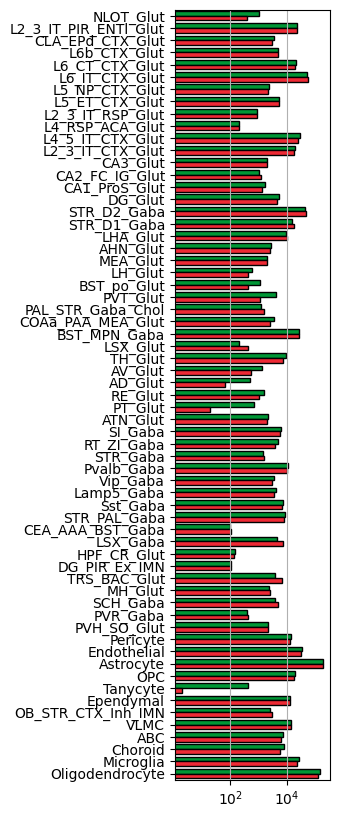

In [54]:
### One bar per genotype
import seaborn as sns



temp = cell_pop#[cell_pop['cell_class']=="Neuron"]
# temp.sort_values(by="count", inplace = True)

plt.figure(figsize=(2,10))

plt.barh(y=temp[temp['genotype']==group1]['celltype'],
         width=temp[temp['genotype']==group1]['count'],
           height = 0.38, align='edge', edgecolor ='black')
plt.barh(y=temp[temp['genotype']==group2]['celltype'],
         width=temp[temp['genotype']==group2]['count'],
           height = -0.38, align='edge', edgecolor ='black')
plt.xscale('log')
plt.grid(axis='x')
plt.ylim(-0.5,62.5)


plt.savefig(f'Gallery/{today}/{name_dir}_cellpop.svg', dpi=300, format = "svg",transparent = True)

# Expressed genes

In [69]:
df_NS.shape[0] + df_SD.shape[0]

1592650

In [49]:
df.columns

Index(['A1cf', 'A2m', 'Aatf', 'Abca1', 'Abca13', 'Abca3', 'Abca4', 'Abca7',
       'Abca8a', 'Abca8b',
       ...
       'ZT', 'run', 'cell_type_final', 'region_automap_name',
       'transcript_counts', 'cell_class', 'circascore', 'x_centroid',
       'y_centroid', 'Neurotransmitter'],
      dtype='object', length=4667)

In [6]:
df_NS = df[(df['run']=='circa4')]
df_SD = df[(df['run']=='SD1')]
del df

In [7]:
df_NS.cell_type_final.unique()

array(['SI_Gaba', 'MEA_Glut', 'Pvalb_Gaba', 'Sst_Gaba', 'PVH_SO_Glut',
       'LHA_Glut', 'BST_MPN_Gaba', 'Oligodendrocyte', 'Astrocyte',
       'Ependymal', 'AHN_Glut', 'VLMC', 'SCH_Gaba', 'ABC', 'Lamp5_Gaba',
       'STR_PAL_Gaba', 'L2_3_IT_PIR_ENTl_Glut', 'STR_Gaba', 'STR_D2_Gaba',
       'L6b_CTX_Glut', 'L2_3_IT_CTX_Glut', 'L6_IT_CTX_Glut',
       'L5_ET_CTX_Glut', 'STR_D1_Gaba', 'COAa_PAA_MEA_Glut', 'OPC',
       'LSX_Gaba', 'NLOT_Glut', 'Endothelial', 'Choroid', 'Pericyte',
       'L4_5_IT_CTX_Glut', 'Microglia', 'CLA_EPd_CTX_Glut',
       'L6_CT_CTX_Glut', 'PAL_STR_Gaba_Chol', 'BST_po_Glut', 'PVT_Glut',
       'PT_Glut', 'RE_Glut', 'OB_STR_CTX_Inh_IMN', 'L5_NP_CTX_Glut',
       'Vip_Gaba', 'RT_ZI_Gaba', 'CA3_Glut', 'CEA_AAA_BST_Gaba',
       'TRS_BAC_Glut', 'LSX_Glut', 'DG_PIR_Ex_IMN', 'HPF_CR_Glut',
       'L2_3_IT_RSP_Glut', 'AV_Glut', 'TH_Glut', 'ATN_Glut', 'PVR_Gaba',
       'CA2_FC_IG_Glut', 'DG_Glut', 'Tanycyte', 'MH_Glut',
       'L4_RSP_ACA_Glut', 'AD_Glut', 'LH_Glut', '

{'ABC': 608,
 'AD_Glut': 639,
 'AHN_Glut': 739,
 'ATN_Glut': 750,
 'AV_Glut': 715,
 'Astrocyte': 504,
 'BST_MPN_Gaba': 750,
 'BST_po_Glut': 744,
 'CA1_ProS_Glut': 713,
 'CA2_FC_IG_Glut': 691,
 'CA3_Glut': 689,
 'CEA_AAA_BST_Gaba': 756,
 'CLA_EPd_CTX_Glut': 703,
 'COAa_PAA_MEA_Glut': 742,
 'Choroid': 674,
 'DG_Glut': 698,
 'DG_PIR_Ex_IMN': 758,
 'Endothelial': 480,
 'Ependymal': 649,
 'HPF_CR_Glut': 686,
 'L2_3_IT_CTX_Glut': 748,
 'L2_3_IT_PIR_ENTl_Glut': 696,
 'L2_3_IT_RSP_Glut': 732,
 'L4_5_IT_CTX_Glut': 717,
 'L4_RSP_ACA_Glut': 723,
 'L5_ET_CTX_Glut': 715,
 'L5_NP_CTX_Glut': 712,
 'L6_CT_CTX_Glut': 697,
 'L6_IT_CTX_Glut': 587,
 'L6b_CTX_Glut': 714,
 'LHA_Glut': 734,
 'LH_Glut': 726,
 'LSX_Gaba': 730,
 'LSX_Glut': 658,
 'Lamp5_Gaba': 686,
 'MEA_Glut': 761,
 'MH_Glut': 621,
 'Microglia': 564,
 'NLOT_Glut': 737,
 'OB_STR_CTX_Inh_IMN': 653,
 'OPC': 631,
 'Oligodendrocyte': 517,
 'PAL_STR_Gaba_Chol': 731,
 'PT_Glut': 744,
 'PVH_SO_Glut': 743,
 'PVR_Gaba': 625,
 'PVT_Glut': 722,
 'Pericyte

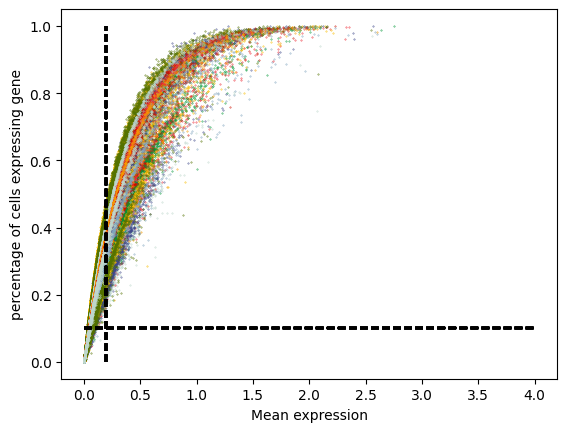

In [8]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k_circa')
NS_dict_pos = {}
# mean_expr = df_NS.groupby('cell_type_final')[clock_genes].mean()
# expr_frac = df_NS[clock_genes].gt(0).groupby(df_NS['cell_type_final']).mean()

gene_columns = df_NS[clock_genes]
grouped = df_NS.groupby('cell_type_final')


for cell_type, group in grouped:
    # group.reindex()
    gene_presence_pct = group[clock_genes].mean()
    gene_pct = group[clock_genes].gt(0).mean()
    # plt.figure()
    # plt.title(cell_type)
    plt.scatter(x=gene_presence_pct, y=gene_pct,s=0.1)
    expressed_genes = gene_presence_pct[((gene_presence_pct >= 0.2) & (gene_pct >= 0.1))].index.tolist()
    NS_dict_pos[cell_type] = expressed_genes
    
    plt.hlines(y=0.1, xmin=0, xmax=4, linestyles="dashed", color = "black")
    plt.vlines(x=0.2, ymin=0, ymax=1, linestyles="dashed", color = "black")
    plt.xlabel('Mean expression')
    plt.ylabel('percentage of cells expressing gene')


NS_dict_nb_gene = {}

for key in NS_dict_pos.keys():
    NS_dict_nb_gene[key]=len(NS_dict_pos[key])
NS_dict_nb_gene


In [9]:
set_NS_common = set()
set_NS = set()

for cell_type in NS_dict_pos.keys():
    temp = NS_dict_pos[cell_type]
    temp_set = set(temp)
    set_NS.update(temp_set)
    if len(set_NS_common) == 0:
        set_NS_common = temp_set
    else:
        set_NS_common = set_NS_common.intersection(temp_set)

len(set_NS),len(set_NS_common)

(2386, 120)

In [10]:
set_NS_common

{'Acox1',
 'Acsl6',
 'Actr2',
 'Agpat3',
 'Aldoa',
 'Amfr',
 'Ap2b1',
 'App',
 'Arhgef12',
 'Atn1',
 'Atp1b2',
 'Atp2a2',
 'Atp5f1',
 'Atp5o',
 'Atp6v1a',
 'Atxn10',
 'Bmpr2',
 'Canx',
 'Caprin1',
 'Cbx3',
 'Cct5',
 'Cct8',
 'Cd81',
 'Chd4',
 'Ckb',
 'Cltc',
 'Crk',
 'Csde1',
 'Ctnnb1',
 'Cul3',
 'Dctn2',
 'Ddx6',
 'Dpysl2',
 'Dst',
 'Dync1h1',
 'Ehmt2',
 'Eif4g1',
 'Elavl1',
 'Etnk1',
 'Gabbr1',
 'Glg1',
 'Gmfb',
 'Gnao1',
 'Gnb1',
 'Grk2',
 'Gsk3a',
 'Gtf2i',
 'Hnrnpa1',
 'Hnrnph1',
 'Hnrnpm',
 'Hspa5',
 'Impact',
 'Khdrbs1',
 'Kif1b',
 'Kif5b',
 'Kpnb1',
 'Lamp1',
 'Ldhb',
 'Lrp1',
 'Map1b',
 'Map1lc3a',
 'Mbd3',
 'Mib1',
 'Mprip',
 'Mtch1',
 'Nbr1',
 'Ndrg2',
 'Nedd4',
 'Nfe2l1',
 'Ntrk2',
 'Ogdh',
 'Paip1',
 'Pdia3',
 'Pgk1',
 'Picalm',
 'Pink1',
 'Pja2',
 'Pkm',
 'Ppp2ca',
 'Ppp2r1a',
 'Ppt1',
 'Prkar1a',
 'Prpf8',
 'Prrc2b',
 'Pten',
 'Ptpa',
 'Rab5a',
 'Rab6a',
 'Rab7',
 'Rac1',
 'Rad23b',
 'Rbbp4',
 'Rnf10',
 'Rnf14',
 'Rsrp1',
 'Rtn3',
 'Rtn4',
 'Saraf',
 'Sdha',
 'Sdhb',
 'S

{'ABC': 597,
 'AD_Glut': 717,
 'AHN_Glut': 724,
 'ATN_Glut': 773,
 'AV_Glut': 755,
 'Astrocyte': 469,
 'BST_MPN_Gaba': 744,
 'BST_po_Glut': 740,
 'CA1_ProS_Glut': 728,
 'CA2_FC_IG_Glut': 704,
 'CA3_Glut': 694,
 'CEA_AAA_BST_Gaba': 745,
 'CLA_EPd_CTX_Glut': 709,
 'COAa_PAA_MEA_Glut': 744,
 'Choroid': 651,
 'DG_Glut': 733,
 'DG_PIR_Ex_IMN': 750,
 'Endothelial': 450,
 'Ependymal': 636,
 'HPF_CR_Glut': 716,
 'L2_3_IT_CTX_Glut': 747,
 'L2_3_IT_PIR_ENTl_Glut': 692,
 'L2_3_IT_RSP_Glut': 725,
 'L4_5_IT_CTX_Glut': 706,
 'L4_RSP_ACA_Glut': 710,
 'L5_ET_CTX_Glut': 718,
 'L5_NP_CTX_Glut': 720,
 'L6_CT_CTX_Glut': 719,
 'L6_IT_CTX_Glut': 539,
 'L6b_CTX_Glut': 706,
 'LHA_Glut': 730,
 'LH_Glut': 769,
 'LSX_Gaba': 732,
 'LSX_Glut': 697,
 'Lamp5_Gaba': 687,
 'MEA_Glut': 768,
 'MH_Glut': 680,
 'Microglia': 529,
 'NLOT_Glut': 723,
 'OB_STR_CTX_Inh_IMN': 666,
 'OPC': 616,
 'Oligodendrocyte': 513,
 'PAL_STR_Gaba_Chol': 734,
 'PT_Glut': 778,
 'PVH_SO_Glut': 753,
 'PVR_Gaba': 579,
 'PVT_Glut': 701,
 'Pericyte

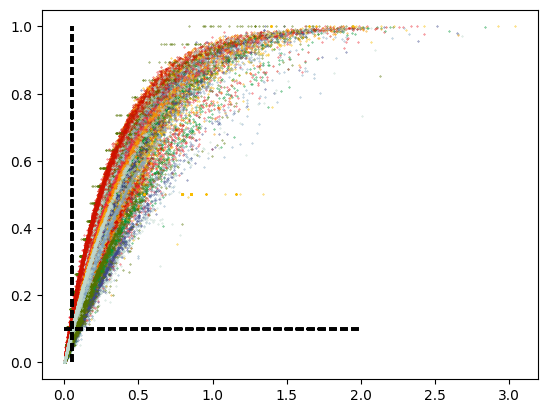

In [11]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k_circa')
SD_dict_pos = {}
# mean_expr = df_SD.groupby('cell_type_final')[clock_genes].mean()
# expr_frac = df_SD[clock_genes].gt(0).groupby(df_SD['cell_type_final']).mean()
# gene_columns = df_SD[clock_genes]

grouped = df_SD.groupby('cell_type_final')


for cell_type, group in grouped:
    # group.reindex()
    gene_presence_pct = group[clock_genes].mean()
    gene_pct = group[clock_genes].gt(0).mean()
    plt.scatter(x=gene_presence_pct, y=gene_pct,s=0.1)
    plt.hlines(y=0.1, xmin=0, xmax=2, linestyles="dashed", color = "black")
    plt.vlines(x=0.05, ymin=0, ymax=1, linestyles="dashed", color = "black")
    expressed_genes = gene_presence_pct[(
        (gene_presence_pct >= 0.2)&(gene_pct >= 0.1)
                                         )].index.tolist()
    SD_dict_pos[cell_type] = expressed_genes

SD_dict_nb_gene = {}

for key in SD_dict_pos.keys():
    SD_dict_nb_gene[key]=len(SD_dict_pos[key])
SD_dict_nb_gene


In [12]:
set_SF_common = set()
set_SF = set()

for cell_type in NS_dict_pos.keys():
    temp = SD_dict_pos[cell_type]
    temp_set = set(temp)
    set_SF.update(temp_set)
    if len(set_SF_common) == 0:
        set_SF_common = temp_set
    else:
        set_SF_common = set_SF_common.intersection(temp_set)

len(set_SF),len(set_SF_common)

(2488, 46)

In [13]:
set_SF_common

{'Aldoa',
 'Amfr',
 'Arhgef12',
 'Atn1',
 'Atp1b2',
 'Atp2a2',
 'Atp5f1',
 'Atp5o',
 'Atp6v1a',
 'Atp6v1b2',
 'Canx',
 'Cd81',
 'Ckb',
 'Cltc',
 'Cpsf6',
 'Ctnnb1',
 'Dst',
 'Etnk1',
 'Gsk3a',
 'Hspa5',
 'Khdrbs1',
 'Klc1',
 'Lamp1',
 'Lrp1',
 'Map1b',
 'Mprip',
 'Mtch1',
 'Ndrg2',
 'Nedd4',
 'Nfe2l1',
 'Ntrk2',
 'Ppp2ca',
 'Ppt1',
 'Prkar1a',
 'Prpf8',
 'Rac1',
 'Rbbp4',
 'Rsrp1',
 'Saraf',
 'Sptan1',
 'Srrm1',
 'Tardbp',
 'Ube3a',
 'Vamp2',
 'Ywhae',
 'Ywhaz'}

In [18]:
# common_NS_SF = set_NS_common.intersection(set_SF_common)
# diff_NS_SF = set_NS_common.difference(set_SF_common)

common_NS_SF = set_SF_common.intersection(set_NS_common)
diff_NS_SF = set_SF_common.difference(set_NS_common)

common_NS_SF
# len(diff_NS_SF)

{'Aldoa',
 'Amfr',
 'Arhgef12',
 'Atn1',
 'Atp1b2',
 'Atp2a2',
 'Atp5f1',
 'Atp5o',
 'Atp6v1a',
 'Canx',
 'Cd81',
 'Ckb',
 'Cltc',
 'Ctnnb1',
 'Dst',
 'Etnk1',
 'Gsk3a',
 'Hspa5',
 'Khdrbs1',
 'Lamp1',
 'Lrp1',
 'Map1b',
 'Mprip',
 'Mtch1',
 'Ndrg2',
 'Nedd4',
 'Nfe2l1',
 'Ntrk2',
 'Ppp2ca',
 'Ppt1',
 'Prkar1a',
 'Prpf8',
 'Rac1',
 'Rbbp4',
 'Rsrp1',
 'Saraf',
 'Sptan1',
 'Tardbp',
 'Ube3a',
 'Ywhaz'}

In [19]:
set_all = set_NS
set_all.update(set_SF)
len(set_all) ## Expressed in at least one celltype accross all 12 samples

2556

In [235]:
set_all

{'Vav1',
 'Cbx5',
 'Cdk5r1',
 'Sept8',
 'Calcrl',
 'Myh9',
 'Arrdc3',
 'Ss18l1',
 'Stk32a',
 'Syt6',
 'Nid1',
 'Pdgfb',
 'Sstr1',
 'Csnk1a1',
 'Bdh1',
 'Slc16a8',
 'Sh3gl3',
 'Fam49b',
 'Grm3',
 'Slc19a1',
 'Limd1',
 'Med24',
 'F3',
 'Syk',
 'P4hb',
 'Srr',
 'Cplx3',
 'Vegfa',
 'Prpf4b',
 'Camsap3',
 'Plekha5',
 'Pik3cg',
 'Lrpprc',
 'Cntnap4',
 'Wnt6',
 'Scn3b',
 'Sost',
 'Hnrnpdl',
 'Cfap61',
 'Rxrg',
 'Vcp',
 'Uchl1',
 'Cops2',
 'Aif1l',
 'Il22',
 'Hnrnph1',
 'Nod1',
 'Fap',
 'Cd14',
 'Slc7a10',
 'Meis1',
 'Fubp1',
 'Nectin2',
 'Tspyl2',
 'Bad',
 'Smpd4',
 'Scrt1',
 'Slc2a1',
 'Cemip',
 'Syne1',
 'Tnfrsf11a',
 'Cd9',
 'Trp73',
 'Adra1b',
 'Snx6',
 'Jade2',
 'Rcc2',
 'Cfap52',
 'Spink8',
 'Sort1',
 'Dsp',
 'Arhgef7',
 'Kcnab2',
 'Lrp1',
 'Ank1',
 'Arhgap44',
 'Bicd2',
 'Cd53',
 'Smad2',
 'Sorl1',
 'Fosl2',
 'Nt5e',
 'Bnc2',
 'Sox4',
 'Hsd17b4',
 'Ywhaz',
 'Park7',
 'Gba2',
 'Kras',
 'Impact',
 'Npc1',
 'Hipk2',
 'Chrna7',
 'Zfp503',
 'Naaa',
 'Notch2',
 'Usp2',
 'Nid2',
 'Huwe1',
 'K

In [21]:
panel_set = set(clock_genes)
not_exp = panel_set.difference(set_all)
print(len(panel_set), len(not_exp))
print(*not_exp)

4655 2099
Edar Ncbp2 Rcor1 Ksr2 Rab27a Tsg101 Thpo Vangl2 Ndufs4 Casp7 Hoxa10 Fancl Glp1r Nod2 Rec8 Ctsk Gdf15 Ifnlr1 Lpin3 Cxcr2 Cdh23 Eed Rb1cc1 Phox2a Mc3r Inhba Il2rb F2rl1 Chrnb3 Ercc2 Slc2a2 Wnt8b Hace1 Pgr Slc18a2 Crhr2 Colgalt2 Cdc20 Kdm1a Tmem108 Sirt1 Zfpl1 Gpat2 Gnrhr Eipr1 Krt28 Ifit1 Adprhl1 Cst7 Lamb3 Grp Neu1 Selenov Il1f5 Dgat1 Sirt5 Baz1a F9 Prph Smad6 Chrm5 Npas1 Cyp3a13 Ucp1 Inka2 Angpt4 Tdgf1 Cd244a Erbb3 Prr5 Tap1 Slco4c1 Sema4a Alox5 Elf3 Foxi1 Ror1 Esrrb Babam2 Stac Pirb Arid3b Zbtb8b Vav2 Cngb3 Rabep2 Ptprq Emc2 Gcat Casq1 Ern2 Psmd13 Gal Ripk1 Ebi3 Pnpla3 Sprr2d Tmem43 Tnfsf9 Zbtb4 C4bp Cacng1 Nlrc4 Mybph Cep104 Ezh1 Gigyf2 Fah Apba3 Tfap2c Yes1 Dazl Psmd11 Casp2 Grb7 Chrna2 Ephb3 Kdf1 Hsd17b7 Slc44a5 Epha1 Knl1 Cdk1 Mlph Tmprss4 Mcph1 Tfam Kcnk10 Fgf10 Frzb Ly6g6e Trex1 Gpr20 Kif4 Gsdma3 Rhot2 Apip Pou1f1 Memo1 Fgg Champ1 Apobec1 Dock3 Ppp1r3a Abitram Aurkb Igkc Rbl1 Abca8b Ntf3 Spo11 Fgf7 Cxcl13 Rela Epha2 Itgb6 Gast Nxph2 Trim17 Hpd Ccdc184 Adm Aqp2 Cercam H

In [23]:
2556/5006*100


51.05872952457051

In [11]:
gene_nb = [len(dict_pos[key]) for key in NS_dict_pos.keys()]
gene_nb

[730,
 823,
 906,
 452,
 1244,
 662,
 471,
 528,
 234,
 1229,
 231,
 630,
 884,
 1152,
 881,
 435,
 612,
 463,
 788,
 464,
 1294,
 1181,
 780,
 1272,
 863,
 1086,
 659,
 1198,
 1130,
 759,
 1109,
 915,
 378,
 479,
 760,
 678,
 171,
 528,
 883,
 1097,
 760,
 522,
 1023,
 1023,
 886,
 644,
 1217,
 816,
 565,
 881,
 909,
 840,
 709,
 920,
 993,
 1085,
 750,
 1021,
 1054,
 949,
 515,
 631,
 1374]

In [37]:
ertg = pd.DataFrame(data={"NS":NS_dict_nb_gene.values(), "SF":SD_dict_nb_gene.values()}, index = NS_dict_nb_gene.keys())


In [38]:
ertg['diff'] = ertg['NS'] - ertg['SF']
ertg

,NS,SF,diff
ABC,608,597,11
AD_Glut,639,717,-78
AHN_Glut,739,724,15
ATN_Glut,750,773,-23
AV_Glut,715,755,-40
Astrocyte,504,469,35
BST_MPN_Gaba,750,744,6
BST_po_Glut,744,740,4
CA1_ProS_Glut,713,728,-15
CA2_FC_IG_Glut,691,704,-13


In [41]:
ertg_noTan = ertg.drop('Tanycyte',axis=0)

In [39]:
ertg.to_csv('../notebook/analysis/circa-SD/genexpression-summary.csv')

In [42]:
[ertg_noTan['NS'].mean(), ertg_noTan['SF'].mean()]

[688.758064516129, 689.4677419354839]

In [43]:
[ertg_noTan['NS'].max(), ertg_noTan['SF'].max()]

[761, 778]

In [44]:
[ertg_noTan['NS'].min(), ertg_noTan['SF'].min()]

[480, 450]

In [45]:
a = [ertg_noTan['NS'].values]
b = [ertg_noTan['SF'].values]
c = np.concatenate((a,b), axis = 1)

c.mean()

689.1129032258065

In [46]:
ertg["celltype"] = ertg.index
ertg["Celltype_order"] = pd.Categorical(ertg["celltype"], categories=order_list, ordered = True)

ertg.sort_values('Celltype_order', inplace= True)

In [47]:
ertg.head()

,NS,SF,diff,celltype,Celltype_order
Oligodendrocyte,517,513,4,Oligodendrocyte,Oligodendrocyte
Microglia,564,529,35,Microglia,Microglia
Choroid,674,651,23,Choroid,Choroid
ABC,608,597,11,ABC,ABC
VLMC,551,528,23,VLMC,VLMC


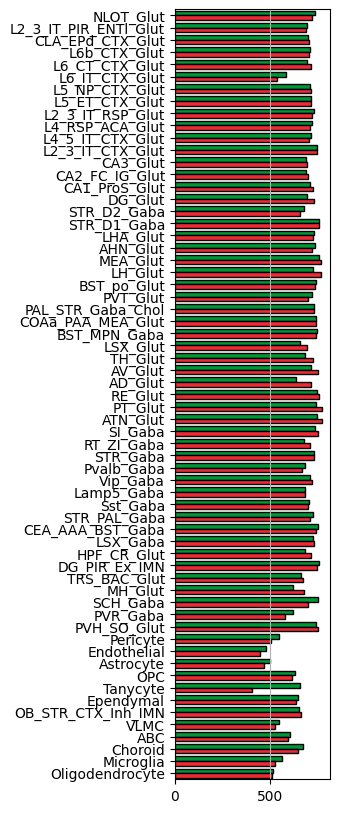

In [51]:
### One bar per genotype
import seaborn as sns

plt.figure(figsize=(2,10))

plt.barh(y=ertg.index,
         width=ertg['NS'],
           height = 0.38, align='edge', edgecolor ='black', label = "NS")
plt.barh(y=ertg.index,
         width=ertg['SF'],
           height = -0.38, align='edge', edgecolor ='black', label = "SF")
# plt.xscale('log')
plt.grid(axis='x')
plt.ylim(-0.5,62.5)


plt.savefig(f'Gallery/{today}/{name_dir}_gene_exp.svg', dpi=300, format = "svg",transparent = True)

# Ratio of cell expressing genes

In [ ]:
# NS
from module.misc import genes_list
import pandas as pd
import pickle

with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

clock = genes_list('clock')

dfdf = pd.DataFrame(index=clock)

for cell in dict_all_cycling.keys():
    
    dfdf[cell] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=="circa4"]['pct_nz_group'][clock].values

In [ ]:
import seaborn as sns

sns.clustermap(dfdf.T, cmap = 'Blues', vmin= 0,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None,figsize=(5,10),
                )
plt.title('Percentage of cells expressing CG')
plt.savefig(f'Gallery/{today}/NS_corr_cyclinggenes_ordernbcycgenes_otherrange.svg',dpi=300)

In [ ]:
# SF
from module.misc import genes_list
import pandas as pd
import pickle

with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

clock = genes_list('clock')

dfdf = pd.DataFrame(index=clock)

for cell in dict_all_cycling.keys():
    
    dfdf[cell] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=="SD1"]['pct_nz_group'][clock].values

import seaborn as sns

sns.clustermap(dfdf.T, cmap = 'Blues', vmin= 0,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None,figsize=(5,10),
                )
plt.title('Percentage of cells expressing CG')
plt.savefig(f'Gallery/{today}/SF_corr_cyclinggenes_ordernbcycgenes_otherrange.svg',dpi=300)

In [21]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k_circa')

In [24]:
df[clock_genes].quantile(0.25)

A1cf      0.0
A2m       0.0
Aatf      0.0
Abca1     0.0
Abca13    0.0
         ... 
Zswim9    0.0
Zup1      0.0
Zyx       0.0
Zzef1     0.0
a         0.0
Name: 0.25, Length: 4655, dtype: float64